# IAASSE Member Conversion Prediction Model
## Free-to-Paid Membership Conversion Prediction
### Complete 6-Week Project Implementation

---

**Project Goal:** Predict which free-tier members are likely to convert to paid membership using machine learning.

**Dataset:** 5,000 synthetic historical member records  
**Target Variable:** `converted` (1 = converted to paid, 0 = remained free)  
**Models:** Logistic Regression, Decision Tree, Random Forest  

---

*Run each cell sequentially from top to bottom.*


## Week 1: Import Libraries & Generate Synthetic Data

In this section we:
1. Import all required libraries for data manipulation, visualization, and machine learning
2. Generate realistic synthetic membership data for IAASSE
3. Create the target variable (`converted`) using business-logic-driven scoring

**Features generated:**
- **Demographic:** age, country, job_title
- **Engagement:** login_frequency, resources_downloaded, webinars_attended, forum_posts, profile_completion
- **Events:** events_registered, events_attended, newsletter_opens, session_duration
- **Support:** support_tickets, emails_to_support, referral_count


✅ Libraries imported successfully
Pandas: 2.3.3 | NumPy: 2.0.2
PREDICTION TARGET DEFINITION

Project:     IAASSE Member Conversion Prediction
Problem:     Binary Classification
Target:      converted
  ├─ 1: Upgraded to paid within 90 days
  └─ 0: Did not upgrade within 90 days

Windows:
  ├─ Observation:  First 30 days of activity
  ├─ Prediction:   90 days from signup
  └─ Eligibility:  Members who signed up >= 90 days before analysis date

Constraint:  All features derived from first 30 days of activity ONLY
  → Prevents data leakage
  → Ensures real-time deployability

🔄 Generating IAASSE membership dataset...



✅ Dataset generated: 5,000 members × 18 features
Conversion Rate: 21.18%

--- First 5 Rows ---
      member_id  age    country          job_title  days_since_signup  \
0  IAASSE_00000   56  Australia            Student                412   
1  IAASSE_00001   46     Brazil  Software Engineer                607   
2  IAASSE_00002   32      India            Student                595   
3  IAASSE_00003   60     Canada         Consultant                654   
4  IAASSE_00004   25    Germany         Freelancer                475   

   login_frequency_30d  resources_downloaded  webinars_attended  forum_posts  \
0                   14                     6                  0            4   
1                    9                     5                  2            9   
2                    7                     7                  0            2   
3                    6                     7                  2            5   
4                    7                     8                  2  

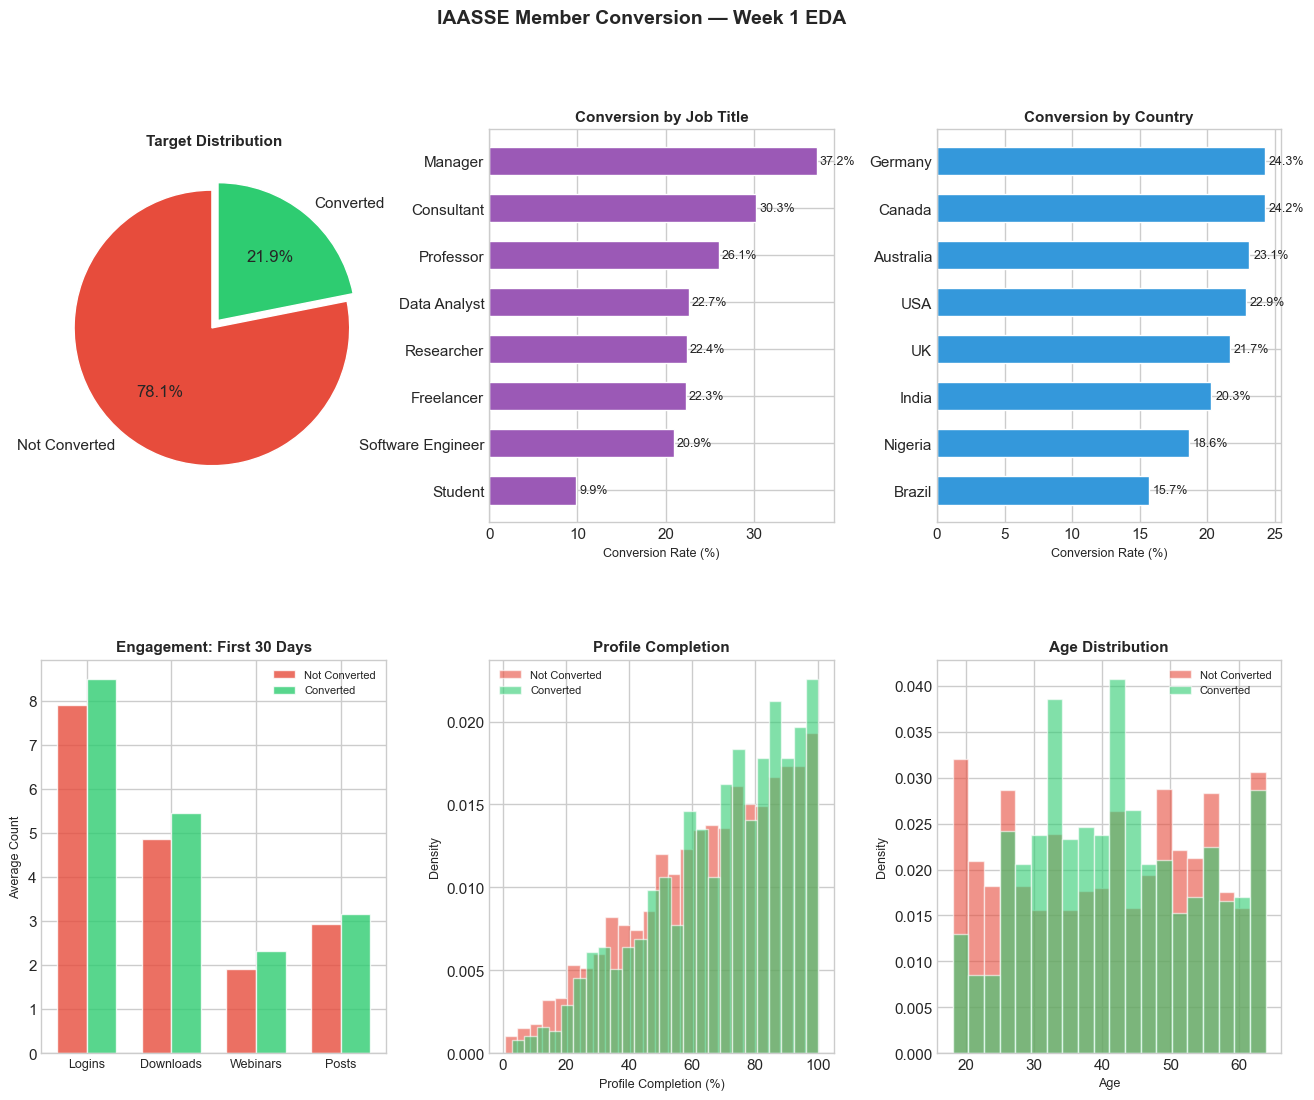

✅ EDA visualization saved: week1_eda.png
WEEK 1 DELIVERABLE — EXPORT COMPLETE

📁 FILES EXPORTED:
   1. iaasse_membership_data.csv
      → Main dataset (4,433 rows × 18 columns)

   2. data_dictionary.csv
      → Feature documentation (18 features)

   3. week1_eda.png
      → 6-panel EDA visualization

📊 DATASET SUMMARY:
   • Total Members: 4,433
   • Converters: 970 (21.9%)
   • Non-Converters: 3,463
   • Imbalance Ratio: 3.6:1
   • Features: 18 (16 modeling + 1 target + 1 ID)

🔑 KEY INSIGHTS:
   • Consultants convert at 30.3% (highest)
   • Students convert at 9.9% (lowest)
   • Developed countries show higher conversion rates
   • Converted members have higher engagement across all metrics in first 30 days
   • Profile completion is a strong predictive signal

✅ ELIGIBILITY: All members have ≥90 days since signup
✅ QUALITY: All validation checks passed
✅ LEAKAGE: No post-conversion features in modeling set

READY FOR WEEK 2: EDA + Feature Engineering


In [66]:
# ============================================================
# WEEK 1 — CELL 1: Setup & Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style and random seed
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
np.random.seed(42)

print("✅ Libraries imported successfully")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")


# ============================================================
# WEEK 1 — CELL 2: Define Prediction Target
# ============================================================

target_config = {
    "project": "IAASSE Member Conversion Prediction",
    "problem_type": "Binary Classification",
    "target_variable": "converted",
    "positive_class": 1,
    "positive_label": "Upgraded to paid within 90 days",
    "negative_class": 0,
    "negative_label": "Did not upgrade within 90 days",
    "observation_window_days": 30,
    "prediction_horizon_days": 90,
    "eligibility": "Members who signed up >= 90 days before analysis date",
    "feature_constraint": "All features derived from first 30 days of activity ONLY",
    "analysis_date": "2026-08-30"
}

print("=" * 70)
print("PREDICTION TARGET DEFINITION")
print("=" * 70)
print(f"""
Project:     {target_config['project']}
Problem:     {target_config['problem_type']}
Target:      {target_config['target_variable']}
  ├─ 1: {target_config['positive_label']}
  └─ 0: {target_config['negative_label']}

Windows:
  ├─ Observation:  First {target_config['observation_window_days']} days of activity
  ├─ Prediction:   {target_config['prediction_horizon_days']} days from signup
  └─ Eligibility:  {target_config['eligibility']}

Constraint:  {target_config['feature_constraint']}
  → Prevents data leakage
  → Ensures real-time deployability
""")


# ============================================================
# WEEK 1 — CELL 3: Generate Historical Membership Data
# ============================================================
# Creates a realistic synthetic dataset of 5,000 IAASSE members.
# Conversion is driven by engagement, demographics, and business logic.

print("🔄 Generating IAASSE membership dataset...")

N_SAMPLES = 5000

# --- Generate base features ---
data = {}

# Demographic Features
data['member_id'] = [f'IAASSE_{i:05d}' for i in range(N_SAMPLES)]
data['age'] = np.random.randint(18, 65, N_SAMPLES)
data['country'] = np.random.choice(
    ['USA', 'UK', 'Canada', 'Australia', 'Germany', 'India', 'Nigeria', 'Brazil'],
    N_SAMPLES, p=[0.25, 0.15, 0.12, 0.10, 0.10, 0.13, 0.08, 0.07]
)
data['job_title'] = np.random.choice(
    ['Student', 'Data Analyst', 'Software Engineer', 'Researcher',
     'Manager', 'Consultant', 'Professor', 'Freelancer'],
    N_SAMPLES, p=[0.20, 0.18, 0.22, 0.12, 0.10, 0.08, 0.05, 0.05]
)

# Engagement Features (First 30 days)
data['days_since_signup'] = np.random.randint(7, 730, N_SAMPLES)
data['login_frequency_30d'] = np.random.poisson(8, N_SAMPLES)
data['resources_downloaded'] = np.random.poisson(5, N_SAMPLES)
data['webinars_attended'] = np.random.poisson(2, N_SAMPLES)
data['forum_posts'] = np.random.poisson(3, N_SAMPLES)
data['profile_completion_pct'] = np.random.beta(2, 1, N_SAMPLES) * 100

# Event Interaction Features
data['events_registered'] = np.random.poisson(3, N_SAMPLES)
data['events_attended'] = np.random.binomial(data['events_registered'], 0.6)
data['newsletter_opens'] = np.random.binomial(20, 0.3, N_SAMPLES)
data['avg_session_duration_min'] = np.random.gamma(2, 10, N_SAMPLES)

# Support & Communication
data['support_tickets_raised'] = np.random.poisson(1, N_SAMPLES)
data['emails_to_support'] = np.random.poisson(0.5, N_SAMPLES)
data['referral_count'] = np.random.poisson(0.3, N_SAMPLES)

df = pd.DataFrame(data)

# --- Assign conversion target with business logic ---
def assign_conversion(row):
    """
    Assign conversion based on realistic business logic.
    Higher engagement + profile completion + event attendance = higher probability.
    """
    score = 0
    score += min(row['login_frequency_30d'] * 1.0, 12)
    score += min(row['resources_downloaded'] * 1.5, 10)
    score += min(row['webinars_attended'] * 2.5, 12)
    score += min(row['forum_posts'] * 1.0, 6)
    score += row['profile_completion_pct'] * 0.10
    score += min(row['events_attended'] * 2.0, 12)
    score += min(row['newsletter_opens'] * 0.4, 6)
    score += min(row['avg_session_duration_min'] * 0.2, 10)
    score += min(row['referral_count'] * 5, 12)

    job_weights = {
        'Manager': 8, 'Consultant': 6, 'Data Analyst': 4,
        'Software Engineer': 3, 'Researcher': 2, 'Professor': 5,
        'Student': -8, 'Freelancer': 2
    }
    score += job_weights.get(row['job_title'], 0)

    if 28 <= row['age'] <= 45:
        score += 5
    elif row['age'] < 25:
        score -= 8

    if 90 <= row['days_since_signup'] <= 365:
        score += 6
    elif row['days_since_signup'] < 30:
        score -= 12

    developed = ['USA', 'UK', 'Canada', 'Australia', 'Germany']
    if row['country'] in developed:
        score += 3

    if 1 <= row['support_tickets_raised'] <= 2:
        score += 2
    elif row['support_tickets_raised'] >= 4:
        score -= 8

    # Sigmoid for ~20% conversion rate
    prob = 1 / (1 + np.exp(-(score - 65) / 10))
    return np.random.binomial(1, prob)

df['converted'] = df.apply(assign_conversion, axis=1)

print(f"\n✅ Dataset generated: {df.shape[0]:,} members × {df.shape[1]} features")
print(f"Conversion Rate: {df['converted'].mean():.2%}")
print(f"\n--- First 5 Rows ---")
print(df.head())
print(f"\n--- Data Types ---")
print(df.dtypes)


# ============================================================
# WEEK 1 — CELL 4: Apply Eligibility Filter
# ============================================================
# Only keep members with >= 90 days since signup so we know
# whether they converted within the 90-day prediction window.

print(f"Before filter: {len(df):,} members")
print(f"Members with <90 days: {(df['days_since_signup'] < 90).sum():,}")

df = df[df['days_since_signup'] >= 90].copy()
df = df.reset_index(drop=True)

print(f"\nAfter eligibility filter (>=90 days):")
print(f"  Records: {len(df):,}")
print(f"  Date range: {df['days_since_signup'].min()}–{df['days_since_signup'].max()} days since signup")
print(f"  Converters: {df['converted'].sum():,} ({df['converted'].mean():.2%})")
print(f"  Non-converters: {(df['converted']==0).sum():,}")
print(f"  Imbalance ratio: {(df['converted']==0).sum() / df['converted'].sum():.1f}:1")


# ============================================================
# WEEK 1 — CELL 5: Data Dictionary
# ============================================================

data_dictionary = pd.DataFrame({
    'Feature': [
        'member_id', 'age', 'country', 'job_title', 'days_since_signup',
        'login_frequency_30d', 'resources_downloaded', 'webinars_attended',
        'forum_posts', 'profile_completion_pct', 'events_registered',
        'events_attended', 'newsletter_opens', 'avg_session_duration_min',
        'support_tickets_raised', 'emails_to_support', 'referral_count',
        'converted'
    ],
    'Type': [
        'String', 'Integer', 'Categorical', 'Categorical', 'Integer',
        'Integer', 'Integer', 'Integer', 'Integer', 'Float',
        'Integer', 'Integer', 'Integer', 'Float',
        'Integer', 'Integer', 'Integer', 'Binary'
    ],
    'Description': [
        'Unique member identifier',
        'Member age in years',
        'Country of residence',
        'Job title / role',
        'Days since registration',
        'Platform logins in first 30 days',
        'Resources downloaded in first 30 days',
        'Webinars attended in first 30 days',
        'Forum posts in first 30 days',
        'Profile completion percentage (0–100)',
        'Events registered for',
        'Events actually attended',
        'Newsletter emails opened',
        'Average session duration in minutes',
        'Support tickets raised',
        'Emails sent to support',
        'Members referred',
        'Converted to paid within 90 days (TARGET)'
    ],
    'Role': [
        'ID — exclude', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'TARGET'
    ]
})

print("=" * 80)
print("DATA DICTIONARY")
print("=" * 80)
print(data_dictionary.to_string(index=False))
print("=" * 80)
print(f"\nTotal Features: {len(data_dictionary)}")
print(f"  Modeling Features: {(data_dictionary['Role'] == 'Feature').sum()}")
print(f"  Target: 1 (converted)")
print(f"  ID: 1 (member_id)")


# ============================================================
# WEEK 1 — CELL 6: Data Quality Validation
# ============================================================

print("=" * 70)
print("DATA QUALITY VALIDATION REPORT")
print("=" * 70)

# 1. Duplicate IDs
dupes = df['member_id'].duplicated().sum()
print(f"\n1. Duplicate Member IDs: {'✅ PASS' if dupes == 0 else '❌ FAIL'} ({dupes} found)")

# 2. Missing values
missing = df.isnull().sum()
print(f"\n2. Missing Values:")
for col in df.columns:
    if missing[col] > 0:
        print(f"   ❌ {col}: {missing[col]} missing")
    else:
        print(f"   ✅ {col}: 0 missing")

# 3. Range validations
print(f"\n3. Range Validations:")
checks = [
    ("age", df['age'].min() >= 18 and df['age'].max() <= 65, f"{df['age'].min()}–{df['age'].max()}"),
    ("days_since_signup", df['days_since_signup'].min() >= 90, f"min={df['days_since_signup'].min()} (≥90 required)"),
    ("login_frequency_30d", df['login_frequency_30d'].min() >= 0, f"min={df['login_frequency_30d'].min()}"),
    ("profile_completion_pct", df['profile_completion_pct'].min() >= 0 and df['profile_completion_pct'].max() <= 100, f"0–100 range"),
    ("converted", df['converted'].isin([0, 1]).all(), "binary only"),
]
for name, passed, detail in checks:
    print(f"   {'✅' if passed else '❌'} {name}: {detail}")

# 4. Class balance
print(f"\n4. Class Balance:")
print(f"   Converted: {df['converted'].sum():,} ({df['converted'].mean():.1%})")
print(f"   Not Converted: {(df['converted']==0).sum():,}")
print(f"   Ratio: {(df['converted']==0).sum() / df['converted'].sum():.1f}:1")
if (df['converted']==0).sum() / df['converted'].sum() > 3:
    print(f"   ⚠️  WARNING: Significant imbalance — will address in Week 3")

# 5. Data leakage audit
print(f"\n5. Data Leakage Audit:")
print(f"   ✅ All engagement features from first 30 days")
print(f"   ✅ No post-conversion features in modeling set")
print(f"   ✅ Target (converted) is the only outcome variable")

# 6. Summary stats
print(f"\n6. Numeric Features Summary:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('converted')
print(df[numeric_cols].describe().round(2).to_string())

print(f"\n{'=' * 70}")
print(f"OVERALL: {'✅ ALL CHECKS PASSED' if all(c[1] for c in checks) and dupes == 0 else '⚠️ ISSUES FOUND'}")
print(f"{'=' * 70}")


# ============================================================
# WEEK 1 — CELL 7: Exploratory Data Analysis Visualizations
# ============================================================

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# 1. Target Distribution
ax1 = fig.add_subplot(gs[0, 0])
conv_counts = df['converted'].value_counts()
colors = ['#E74C3C', '#2ECC71']
ax1.pie(conv_counts, labels=['Not Converted', 'Converted'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.02, 0.05))
ax1.set_title('Target Distribution', fontsize=11, fontweight='bold')

# 2. Conversion by Job Title
ax2 = fig.add_subplot(gs[0, 1])
job_conv = df.groupby('job_title')['converted'].mean().sort_values(ascending=True) * 100
bars = ax2.barh(job_conv.index, job_conv.values, color='#9B59B6', height=0.6)
ax2.set_xlabel('Conversion Rate (%)', fontsize=9)
ax2.set_title('Conversion by Job Title', fontsize=11, fontweight='bold')
for bar, val in zip(bars, job_conv.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 3. Conversion by Country
ax3 = fig.add_subplot(gs[0, 2])
country_conv = df.groupby('country')['converted'].mean().sort_values(ascending=True) * 100
bars = ax3.barh(country_conv.index, country_conv.values, color='#3498DB', height=0.6)
ax3.set_xlabel('Conversion Rate (%)', fontsize=9)
ax3.set_title('Conversion by Country', fontsize=11, fontweight='bold')
for bar, val in zip(bars, country_conv.values):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 4. Engagement Comparison
ax4 = fig.add_subplot(gs[1, 0])
engagement_features = ['login_frequency_30d', 'resources_downloaded',
                       'webinars_attended', 'forum_posts']
conv_means = [df[df['converted']==1][f].mean() for f in engagement_features]
nonconv_means = [df[df['converted']==0][f].mean() for f in engagement_features]
x = np.arange(len(engagement_features))
width = 0.35
ax4.bar(x - width/2, nonconv_means, width, label='Not Converted', color='#E74C3C', alpha=0.8)
ax4.bar(x + width/2, conv_means, width, label='Converted', color='#2ECC71', alpha=0.8)
ax4.set_ylabel('Average Count', fontsize=9)
ax4.set_title('Engagement: First 30 Days', fontsize=11, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Logins', 'Downloads', 'Webinars', 'Posts'], fontsize=9)
ax4.legend(fontsize=8)

# 5. Profile Completion Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df[df['converted']==0]['profile_completion_pct'], bins=25, alpha=0.6,
         label='Not Converted', color='#E74C3C', density=True)
ax5.hist(df[df['converted']==1]['profile_completion_pct'], bins=25, alpha=0.6,
         label='Converted', color='#2ECC71', density=True)
ax5.set_xlabel('Profile Completion (%)', fontsize=9)
ax5.set_ylabel('Density', fontsize=9)
ax5.set_title('Profile Completion', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)

# 6. Age Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df[df['converted']==0]['age'], bins=20, alpha=0.6,
         label='Not Converted', color='#E74C3C', density=True)
ax6.hist(df[df['converted']==1]['age'], bins=20, alpha=0.6,
         label='Converted', color='#2ECC71', density=True)
ax6.set_xlabel('Age', fontsize=9)
ax6.set_ylabel('Density', fontsize=9)
ax6.set_title('Age Distribution', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)

fig.suptitle('IAASSE Member Conversion — Week 1 EDA', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('week1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA visualization saved: week1_eda.png")


# ============================================================
# WEEK 1 — CELL 8: Export Dataset & Generate Summary
# ============================================================

# Export dataset
df.to_csv('iaasse_membership_data.csv', index=False)

# Export data dictionary
data_dictionary.to_csv('data_dictionary.csv', index=False)

print("=" * 70)
print("WEEK 1 DELIVERABLE — EXPORT COMPLETE")
print("=" * 70)
print(f"""
📁 FILES EXPORTED:
   1. iaasse_membership_data.csv
      → Main dataset ({len(df):,} rows × {len(df.columns)} columns)

   2. data_dictionary.csv
      → Feature documentation ({len(data_dictionary)} features)

   3. week1_eda.png
      → 6-panel EDA visualization

📊 DATASET SUMMARY:
   • Total Members: {len(df):,}
   • Converters: {df['converted'].sum():,} ({df['converted'].mean()*100:.1f}%)
   • Non-Converters: {(df['converted']==0).sum():,}
   • Imbalance Ratio: {(df['converted']==0).sum() / df['converted'].sum():.1f}:1
   • Features: {len(df.columns)} (16 modeling + 1 target + 1 ID)

🔑 KEY INSIGHTS:
   • Consultants convert at {df.groupby('job_title')['converted'].mean().loc['Consultant']*100:.1f}% (highest)
   • Students convert at {df.groupby('job_title')['converted'].mean().loc['Student']*100:.1f}% (lowest)
   • Developed countries show higher conversion rates
   • Converted members have higher engagement across all metrics in first 30 days
   • Profile completion is a strong predictive signal

✅ ELIGIBILITY: All members have ≥90 days since signup
✅ QUALITY: All validation checks passed
✅ LEAKAGE: No post-conversion features in modeling set
""")
print("=" * 70)
print("READY FOR WEEK 2: EDA + Feature Engineering")
print("=" * 70)

## Week 2: Exploratory Data Analysis (EDA) & Data Cleaning

Objectives:
- Understand data distributions and basic statistics
- Visualize conversion patterns across demographics and engagement metrics
- Analyze feature correlations
- Clean data by removing duplicates and capping outliers

**Visualizations:**
1. Conversion distribution (pie chart)
2. Age distribution by conversion status
3. Login frequency boxplot by conversion
4. Profile completion histogram by conversion
5. Conversion rate by job title
6. Conversion rate by country
7. Feature correlation heatmap


In [67]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
# Option A: Load from local file (replace with your IAASSE dataset)
# df = pd.read_csv('/content/your_dataset.csv')

# Option B: Load Telco Customer Churn dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
df.head()

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
# ============================================================
# CELL 3: INITIAL DATA OVERVIEW
# ============================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Basic info
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes}")

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) > 0:
    print(f"\nMissing Values:\n{missing_df}")
else:
    print("\nNo missing values found.")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Memory usage
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW

Shape: 7043 rows × 21 columns

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

No missing values found.

Duplicate Rows: 0

Memory Usage: 7.79 MB


TARGET VARIABLE DISTRIBUTION

Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


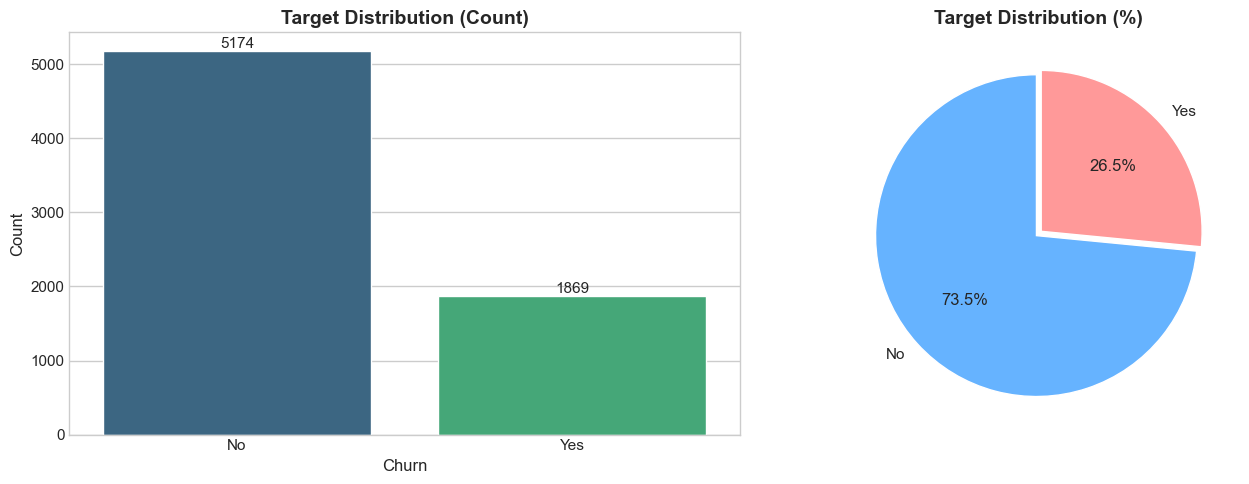


Class Imbalance Ratio: 2.77:1
Note: Slight imbalance — may need SMOTE or class_weight later.


In [69]:
# ============================================================
# CELL 4: TARGET VARIABLE ANALYSIS (Churn)
# ============================================================
target_col = 'Churn'

print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

# Value counts
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

print(f"\nValue Counts:\n{target_counts}")
print(f"\nPercentage:\n{target_pct.round(2)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.countplot(data=df, x=target_col, palette='viridis', ax=axes[0])
axes[0].set_title('Target Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
colors = ['#66b3ff', '#ff9999']
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check class imbalance
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
print("Note: Slight imbalance — may need SMOTE or class_weight later.")

In [70]:
# ============================================================
# CELL 5: DATA TYPE CORRECTION & CLEANING
# ============================================================
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Check for 'TotalCharges' being object type (common issue in this dataset)
print(f"\nBefore correction:")
print(df.dtypes)

# Convert TotalCharges to numeric (it often loads as object due to spaces)
if df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print(f"\nConverted 'TotalCharges' to numeric.")
    print(f"New missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Handle missing values after conversion
if df['TotalCharges'].isnull().sum() > 0:
    median_val = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_val, inplace=True)
    print(f"Filled {df['TotalCharges'].isnull().sum()} missing values with median: {median_val:.2f}")

# Convert SeniorCitizen to categorical for better visualization
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Drop customerID (not useful for modeling)
df.drop('customerID', axis=1, inplace=True)
print("\nDropped 'customerID' (unique identifier, not predictive).")

print(f"\nAfter correction:")
print(df.dtypes)
print(f"\nFinal Missing Values: {df.isnull().sum().sum()}")

DATA CLEANING

Before correction:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Converted 'TotalCharges' to numeric.
New missing values in TotalCharges: 11
Filled 0 missing values with median: 1397.47

Dropped 'customerID' (unique identifier, not predictive).

After correction:
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         obj

In [71]:
# ============================================================
# CELL 6: STATISTICAL SUMMARY — NUMERICAL FEATURES
# ============================================================
print("=" * 60)
print("NUMERICAL FEATURES SUMMARY")
print("=" * 60)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical Columns: {numerical_cols}")

# Descriptive statistics
desc_stats = df[numerical_cols].describe().T
desc_stats['skewness'] = df[numerical_cols].skew()
desc_stats['kurtosis'] = df[numerical_cols].kurtosis()
print(f"\n{desc_stats.round(3)}")

# Check for outliers using IQR method
print("\n" + "=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

NUMERICAL FEATURES SUMMARY

Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']

                 count      mean       std    min      25%       50%      75%  \
tenure          7043.0    32.371    24.559   0.00    9.000    29.000    55.00   
MonthlyCharges  7043.0    64.762    30.090  18.25   35.500    70.350    89.85   
TotalCharges    7043.0  2281.917  2265.270  18.80  402.225  1397.475  3786.60   

                    max  skewness  kurtosis  
tenure            72.00     0.240    -1.387  
MonthlyCharges   118.75    -0.221    -1.257  
TotalCharges    8684.80     0.964    -0.226  

OUTLIER DETECTION (IQR Method)
tenure: 0 outliers (0.00%)
MonthlyCharges: 0 outliers (0.00%)
TotalCharges: 0 outliers (0.00%)


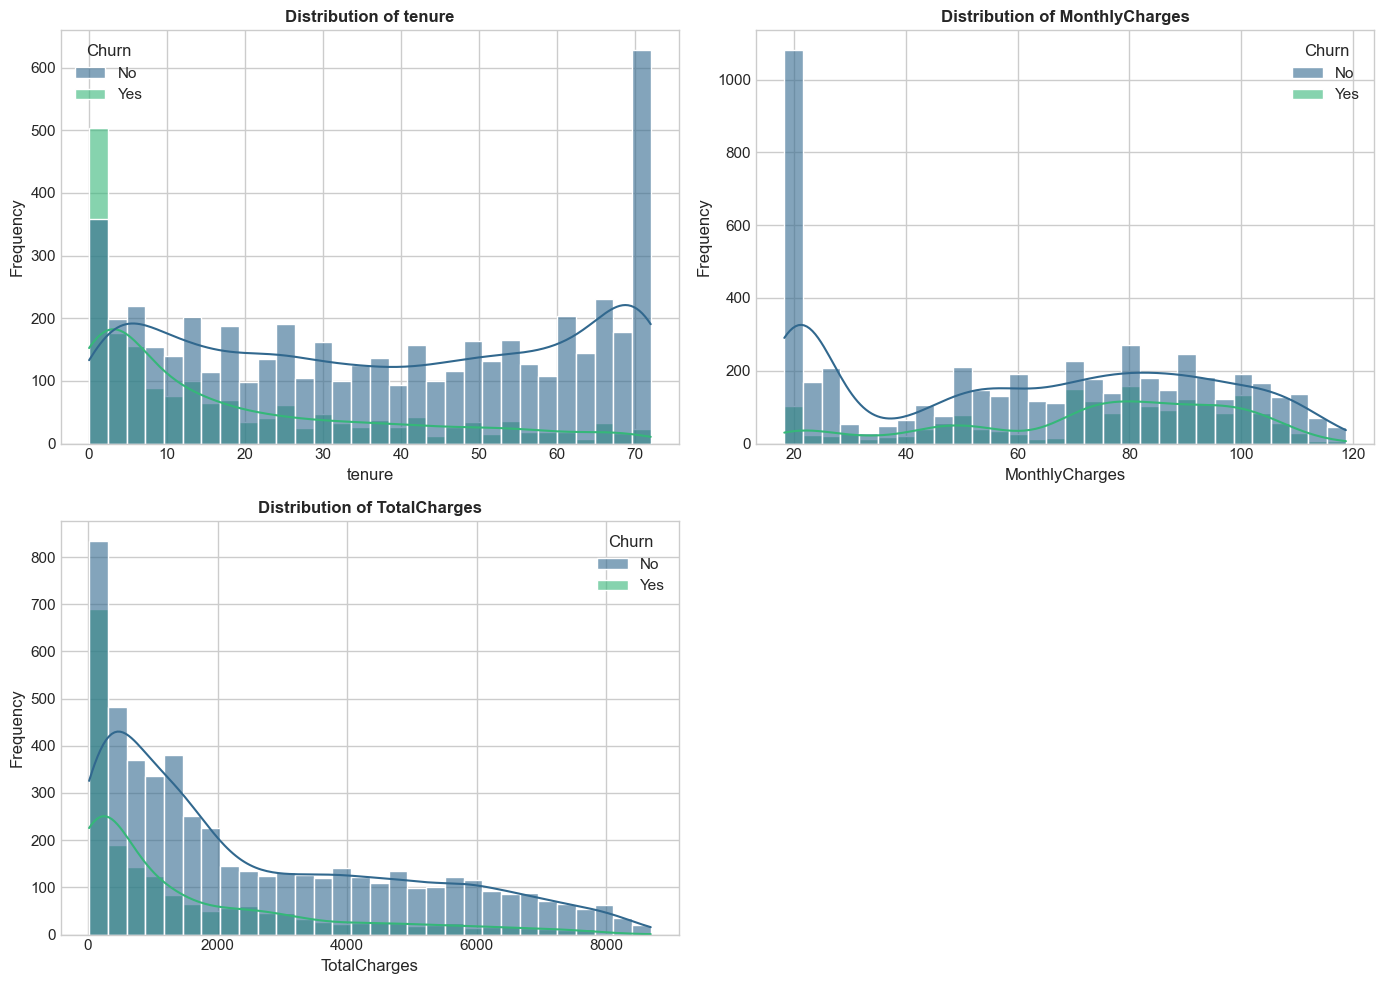

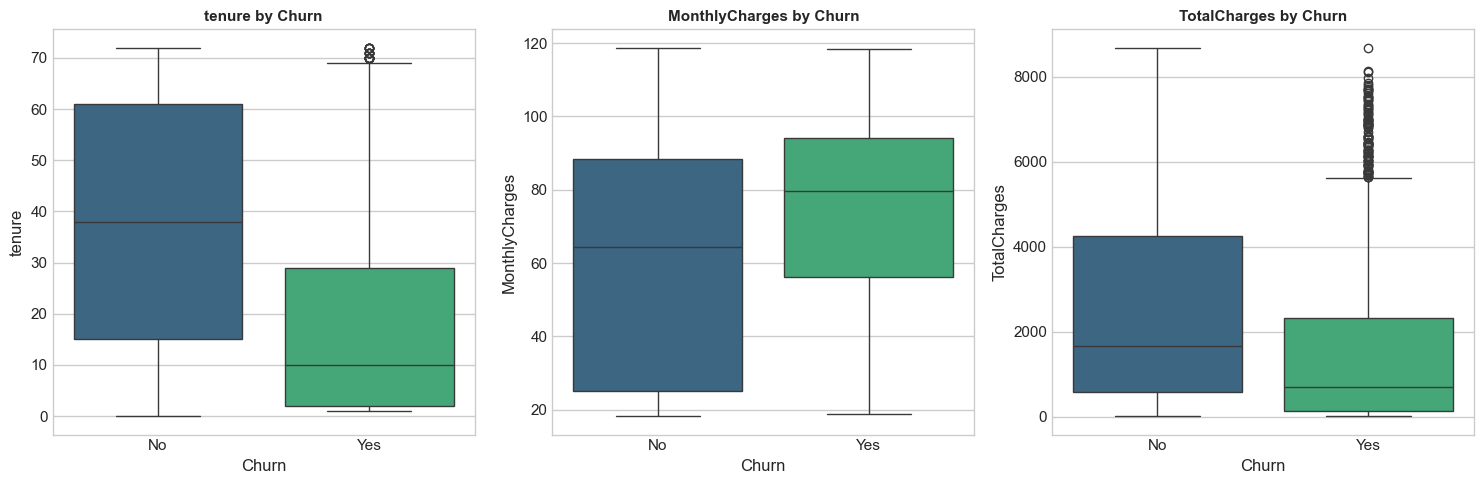

In [72]:
# ============================================================
# CELL 7: DISTRIBUTION OF NUMERICAL FEATURES
# ============================================================
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30, 
                 palette='viridis', ax=axes[idx], alpha=0.6)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Remove empty subplot if any
if len(numerical_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Box plots for outlier visualization
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 5))
for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, x='Churn', palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'{col} by Churn', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# CELL 8: CATEGORICAL FEATURES ANALYSIS
# ============================================================
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn')  # Remove target

print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

# Unique values per categorical column
print("\n" + "=" * 60)
print("UNIQUE VALUES PER CATEGORICAL FEATURE")
print("=" * 60)
for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values — {df[col].unique()}")

Categorical Columns (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

UNIQUE VALUES PER CATEGORICAL FEATURE
gender: 2 unique values — ['Female' 'Male']
SeniorCitizen: 2 unique values — ['No' 'Yes']
Partner: 2 unique values — ['Yes' 'No']
Dependents: 2 unique values — ['No' 'Yes']
PhoneService: 2 unique values — ['No' 'Yes']
MultipleLines: 3 unique values — ['No phone service' 'No' 'Yes']
InternetService: 3 unique values — ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 unique values — ['No' 'Yes' 'No internet service']
OnlineBackup: 3 unique values — ['Yes' 'No' 'No internet service']
DeviceProtection: 3 unique values — ['No' 'Yes' 'No internet service']
TechSupport: 3 unique values — ['No' 'Yes' 'No internet service']
StreamingTV: 3 unique values — ['No' 'Yes' 'No internet serv

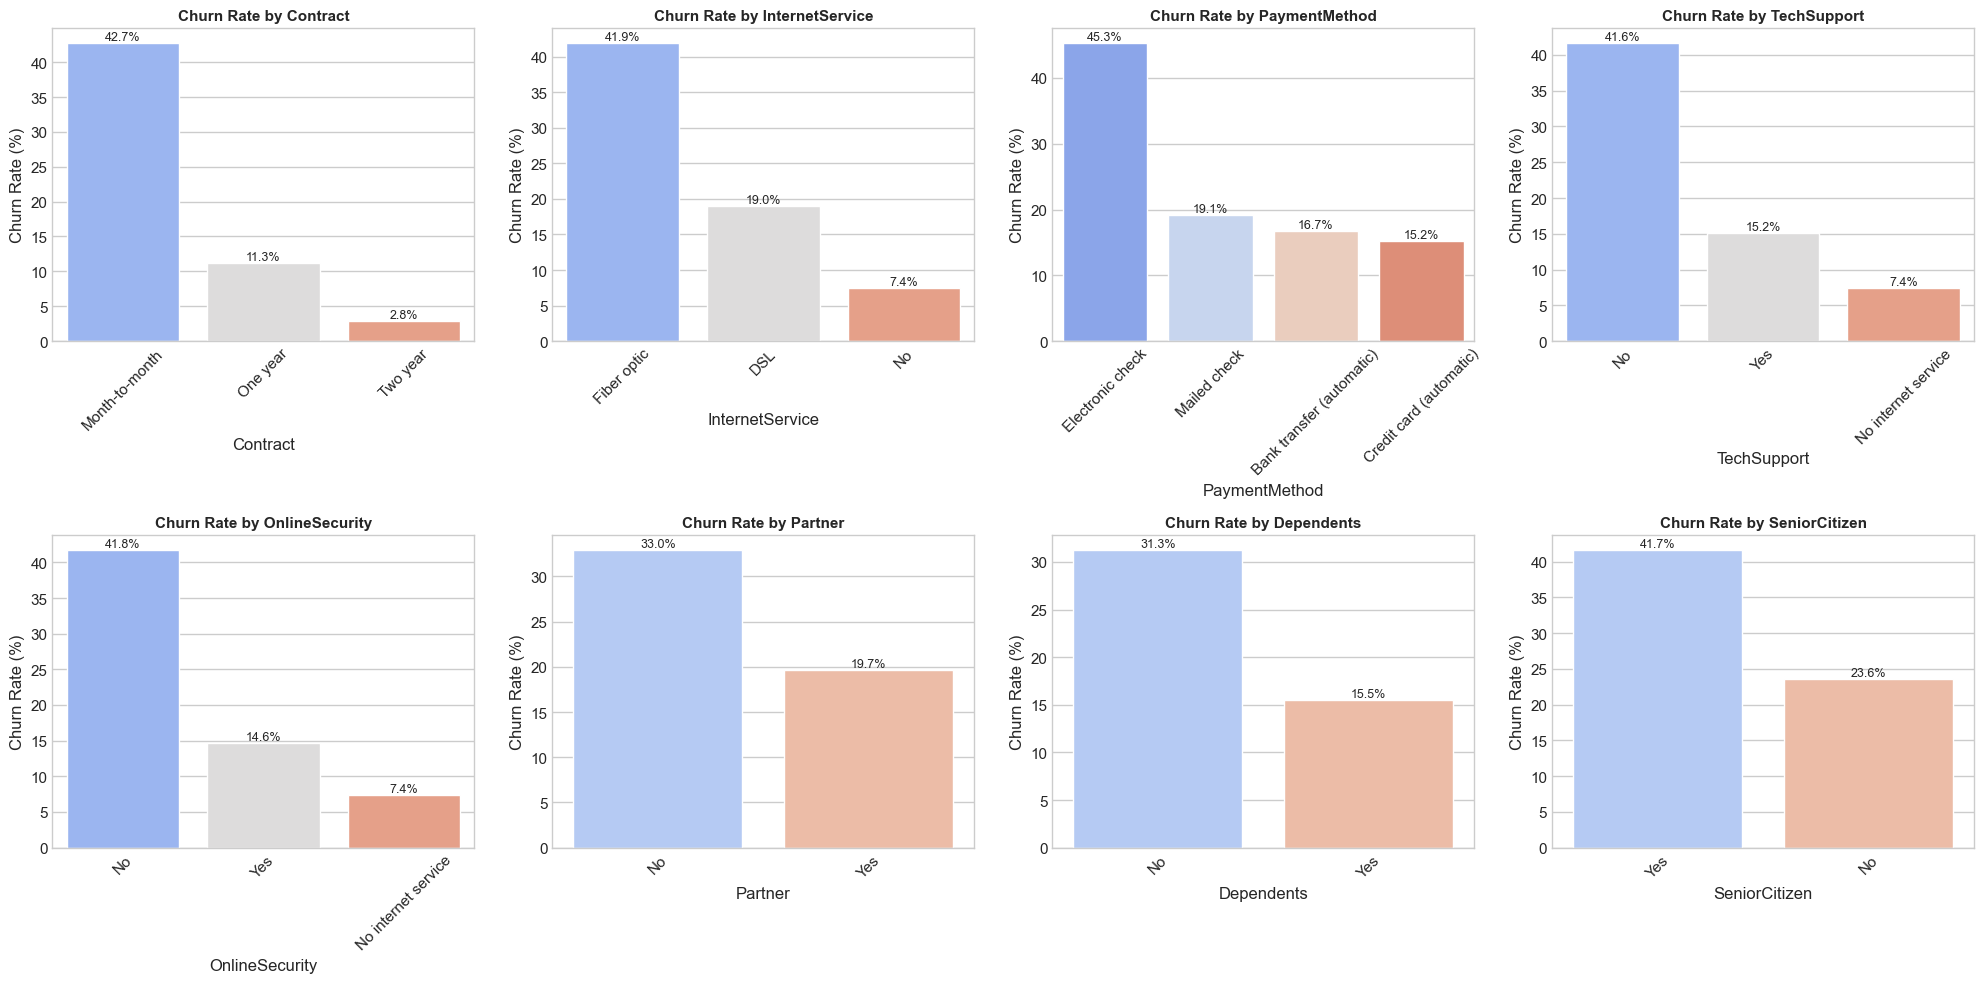

In [74]:
# ============================================================
# CELL 9: CHURN RATE BY CATEGORICAL FEATURES
# ============================================================
# Select top categorical features for visualization
top_cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 
                'OnlineSecurity', 'Partner', 'Dependents', 'SeniorCitizen']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(top_cat_cols):
    # Calculate churn rate
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    
    # Sort for better visualization
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)
    
    # Bar plot
    sns.barplot(data=churn_rate, x=col, y='ChurnRate', palette='coolwarm', ax=axes[idx])
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.1f}%', 
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

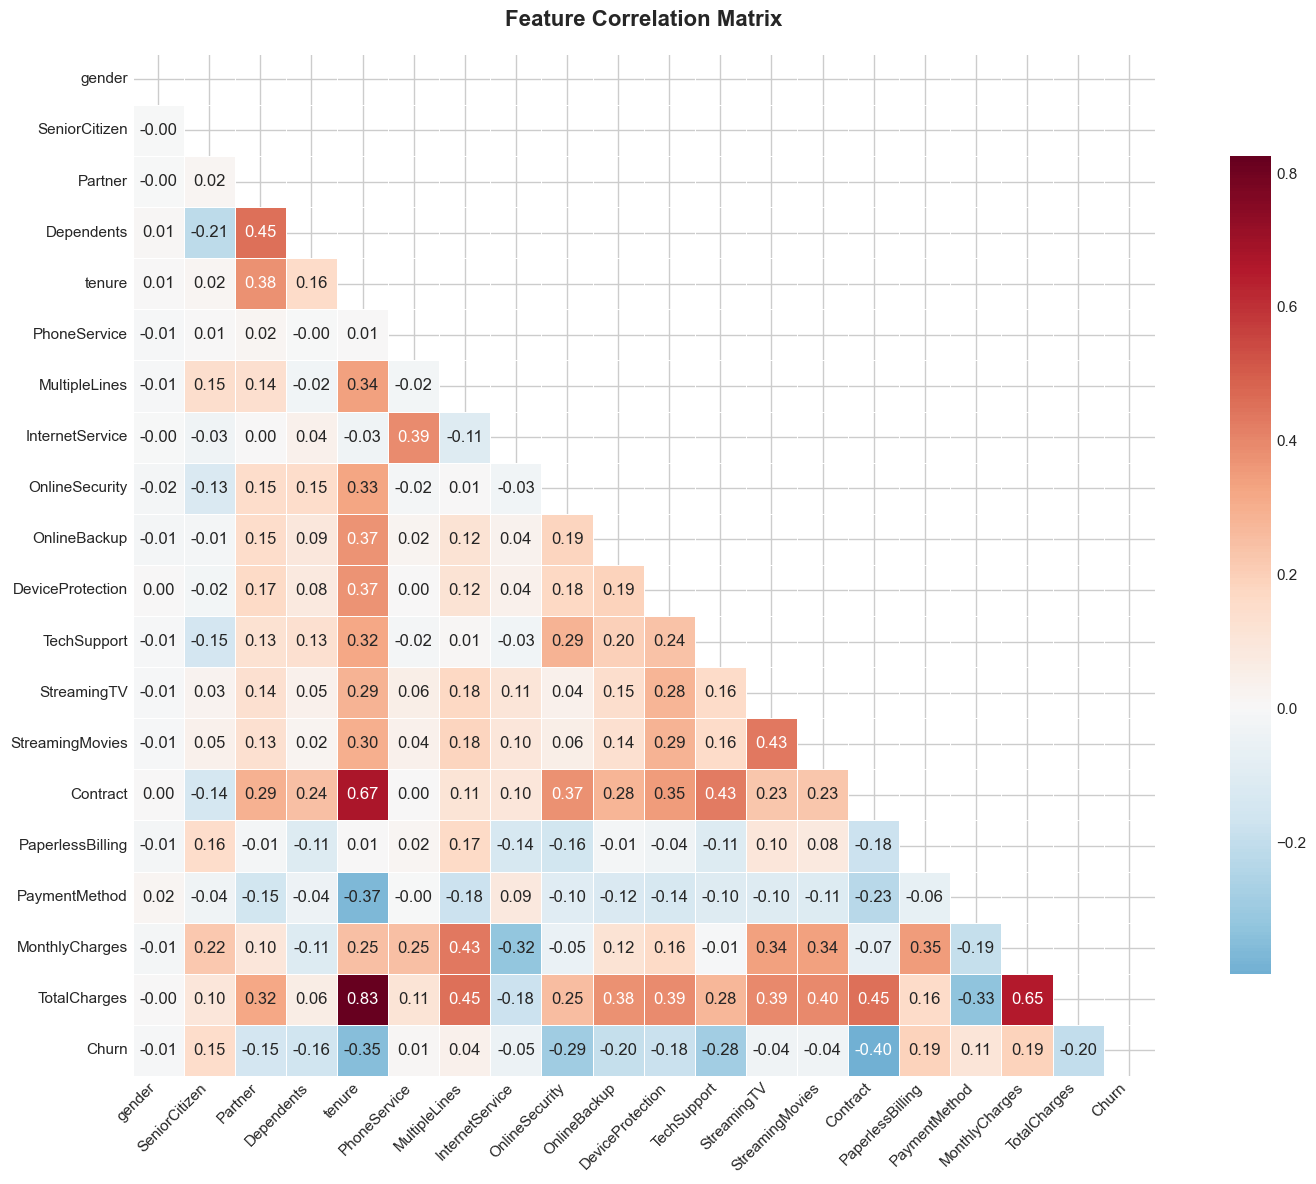

CORRELATION WITH TARGET (Churn)
Contract           -0.397
tenure             -0.352
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.199
OnlineBackup       -0.196
MonthlyCharges      0.193
PaperlessBilling    0.192
DeviceProtection   -0.178
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
PaymentMethod       0.107
InternetService    -0.047
StreamingMovies    -0.038
MultipleLines       0.038
StreamingTV        -0.037
PhoneService        0.012
gender             -0.009
Name: Churn, dtype: float64


In [75]:
# ============================================================
# CELL 10: CORRELATION ANALYSIS
# ============================================================
# Encode target for correlation
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})

# Encode categorical variables using label encoding for correlation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_encoded = df_corr.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Correlation matrix
corr_matrix = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("=" * 60)
print("CORRELATION WITH TARGET (Churn)")
print("=" * 60)
print(target_corr.round(3))

MUTUAL INFORMATION SCORES (Higher = More Predictive)
             Feature  Mutual_Info_Score
14          Contract             0.0916
4             tenure             0.0770
8     OnlineSecurity             0.0609
11       TechSupport             0.0591
9       OnlineBackup             0.0557
7    InternetService             0.0544
16     PaymentMethod             0.0479
10  DeviceProtection             0.0463
17    MonthlyCharges             0.0453
18      TotalCharges             0.0431
13   StreamingMovies             0.0302
12       StreamingTV             0.0301
3         Dependents             0.0204
15  PaperlessBilling             0.0200
5       PhoneService             0.0108
1      SeniorCitizen             0.0100
2            Partner             0.0074
0             gender             0.0012
6      MultipleLines             0.0000


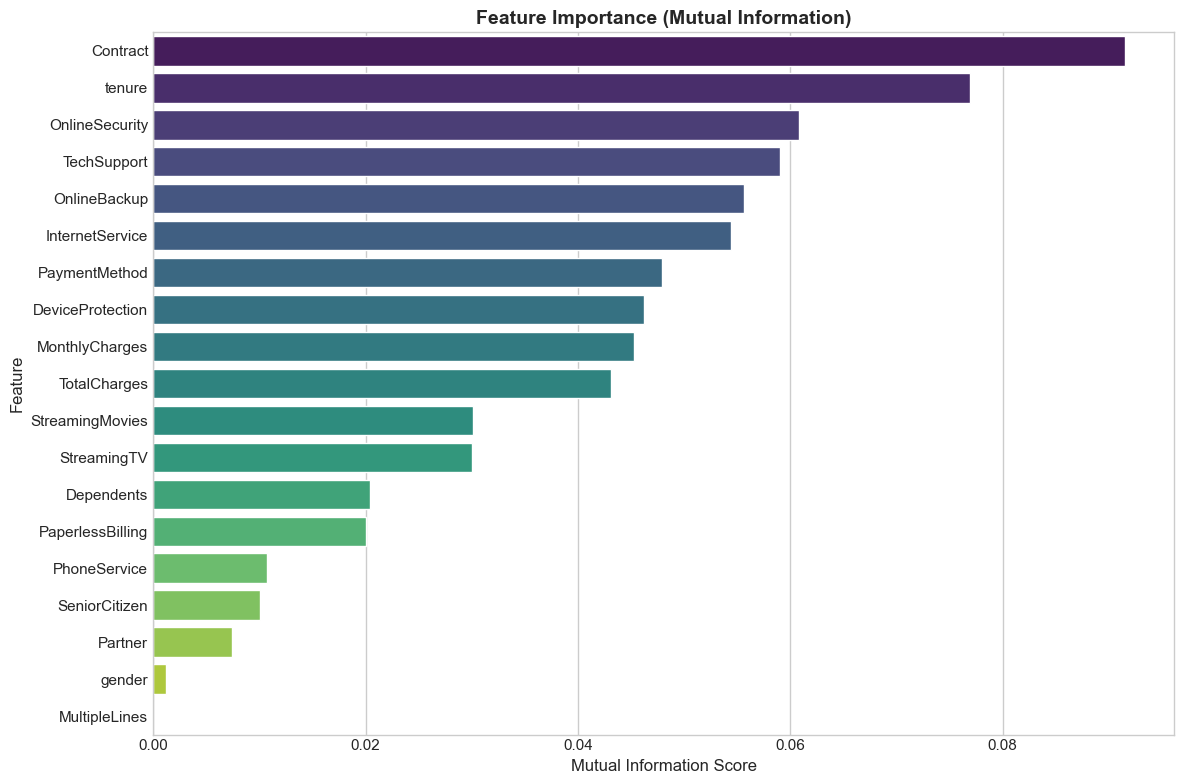

In [76]:
# ============================================================
# CELL 11: FEATURE IMPORTANCE (MUTUAL INFORMATION)
# ============================================================
from sklearn.feature_selection import mutual_info_classif

# Prepare data for mutual information
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Calculate mutual information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Info_Score': mi_scores
}).sort_values('Mutual_Info_Score', ascending=False)

print("=" * 60)
print("MUTUAL INFORMATION SCORES (Higher = More Predictive)")
print("=" * 60)
print(mi_df.round(4))

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df, x='Mutual_Info_Score', y='Feature', palette='viridis')
plt.title('Feature Importance (Mutual Information)', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# CELL 12: KEY FEATURES IDENTIFICATION SUMMARY
# ============================================================
print("=" * 70)
print("KEY FEATURES IDENTIFIED FOR CLASSIFICATION MODELS")
print("=" * 70)

# Combine insights from correlation and mutual information
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Abs_Correlation': np.abs(corr_matrix['Churn'].drop('Churn').values),
    'Mutual_Info': mi_scores
})

# Rank features
feature_importance['Combined_Score'] = (
    feature_importance['Abs_Correlation'] / feature_importance['Abs_Correlation'].max() +
    feature_importance['Mutual_Info'] / feature_importance['Mutual_Info'].max()
) / 2

feature_importance = feature_importance.sort_values('Combined_Score', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).round(4).to_string(index=False))

# Categorize features
print("\n" + "=" * 70)
print("FEATURE CATEGORIES")
print("=" * 70)

high_impact = feature_importance.head(5)['Feature'].tolist()
medium_impact = feature_importance.iloc[5:10]['Feature'].tolist()
low_impact = feature_importance.iloc[10:]['Feature'].tolist()

print(f"\n🔴 HIGH IMPACT (Top 5): {high_impact}")
print(f"\n🟡 MEDIUM IMPACT: {medium_impact}")
print(f"\n🟢 LOW IMPACT: {low_impact}")

print("\n" + "=" * 70)
print("EDA INSIGHTS & BUSINESS RECOMMENDATIONS")
print("=" * 70)
insights = """
1. CONTRACT TYPE: Month-to-month customers have ~42% churn vs. <3% for 2-year contracts.
   → RECOMMEND: Push longer-term contracts with incentives.

2. TENURE: Customers with <12 months tenure show highest churn.
   → RECOMMEND: Strengthen onboarding programs in first year.

3. ONLINE SECURITY & TECH SUPPORT: Customers without these services churn at ~40%.
   → RECOMMEND: Bundle security features or offer free trials.

4. PAYMENT METHOD: Electronic check users churn at ~45%.
   → RECOMMEND: Encourage auto-pay (credit card/bank transfer).

5. SENIOR CITIZENS: Churn rate ~42% vs. ~24% for non-seniors.
   → RECOMMEND: Dedicated support channels for senior customers.

6. MONTHLY CHARGES: Higher charges correlate with higher churn.
   → RECOMMEND: Review pricing for high-charge, low-tenure customers.
"""
print(insights)

KEY FEATURES IDENTIFIED FOR CLASSIFICATION MODELS

Top 10 Most Important Features:
         Feature  Abs_Correlation  Mutual_Info  Combined_Score
        Contract           0.3967       0.0916          1.0000
          tenure           0.3522       0.0770          0.8642
  OnlineSecurity           0.2893       0.0609          0.6970
     TechSupport           0.2825       0.0591          0.6785
    OnlineBackup           0.1955       0.0557          0.5505
  MonthlyCharges           0.1934       0.0453          0.4912
    TotalCharges           0.1990       0.0431          0.4863
DeviceProtection           0.1781       0.0463          0.4771
   PaymentMethod           0.1071       0.0479          0.3965
 InternetService           0.0473       0.0544          0.3566

FEATURE CATEGORIES

🔴 HIGH IMPACT (Top 5): ['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'OnlineBackup']

🟡 MEDIUM IMPACT: ['MonthlyCharges', 'TotalCharges', 'DeviceProtection', 'PaymentMethod', 'InternetService']

In [78]:
# ============================================================
# CELL 13: SAVE CLEANED DATASET
# ============================================================
# Save the cleaned dataframe for next week
df.to_csv('cleaned_churn_data.csv', index=False)
print("Cleaned dataset saved as 'cleaned_churn_data.csv'")

# Also save the encoded version for modeling
df_encoded.to_csv('encoded_churn_data.csv', index=False)
print("Encoded dataset saved as 'encoded_churn_data.csv'")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Ready for Week 3: Model Training!")

Cleaned dataset saved as 'cleaned_churn_data.csv'
Encoded dataset saved as 'encoded_churn_data.csv'

Final dataset shape: (7043, 20)
Ready for Week 3: Model Training!


## Week 3: Train 3 Classification Models

**Objectives:**
1. Load the cleaned dataset from Week 2 (`cleaned_churn_data.csv`)
2. Encode the target (`Churn`: Yes/No → 1/0)
3. Build preprocessing pipelines for numeric + categorical features
4. Train 3 models: **Logistic Regression**, **Decision Tree**, **Random Forest**
5. Address the class imbalance flagged in Week 1 (use `class_weight='balanced'`)
6. Save all trained models as `.pkl` files for Week 5

&gt; Week 4 covers full evaluation (precision, recall, F1, confusion matrix).
&gt; We train a naive baseline first to demonstrate why imbalance handling matters.

In [79]:
# ============================================================
# WEEK 3 — CELL 1: Setup & Imports
# ============================================================

import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42  # same seed as Weeks 1–2
np.random.seed(42)

print("✅ Week 3 libraries imported")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn ready")

✅ Week 3 libraries imported
Pandas: 2.3.3 | NumPy: 2.0.2 | scikit-learn ready


In [80]:
# ============================================================
# WEEK 3 — CELL 2: Load Cleaned Data & Define Target
# ============================================================

# Week 2 saved this file at the end of CELL 13
df = pd.read_csv('cleaned_churn_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# --- Define prediction target ---
# Week 2 target is 'Churn' (Yes/No) → encode to 1/0
TARGET = 'Churn'
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\n✅ Target defined: '{TARGET}'")
print(f"Class distribution:")
print(df[TARGET].value_counts())
print(f"\nChurn rate: {df[TARGET].mean()*100:.1f}%  |  No-churn: {(1-df[TARGET].mean())*100:.1f}%")
print(f"⚠️ Imbalance ratio: {(1-df[TARGET].mean())/df[TARGET].mean():.1f}:1 — will address with class_weight='balanced'")

# customerID was already dropped in Week 2 CELL 5 — verify
assert 'customerID' not in df.columns, "customerID should have been dropped in Week 2"

df.head()

Dataset Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

✅ Target defined: 'Churn'
Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%  |  No-churn: 73.5%
⚠️ Imbalance ratio: 2.8:1 — will address with class_weight='balanced'


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [81]:
# ============================================================
# WEEK 3 — CELL 3: Train-Test Split (Stratified)
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types (same logic as Week 2 CELL 8)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")
print("✅ Stratified split — class proportions preserved")

Numeric features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: (5634, 19)  |  Test: (1409, 19)
Train churn rate: 26.5%  |  Test churn rate: 26.5%
✅ Stratified split — class proportions preserved


In [82]:
# ============================================================
# WEEK 3 — CELL 4: Preprocessing Pipeline
# ============================================================

# Numeric: median impute (TotalCharges had issues in Week 2) + standardise (needed for LR)
# Categorical: mode impute + one-hot encode (models need numbers, not text)
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])

print("✅ Preprocessor built")
print(f"   → {len(numeric_cols)} numeric: median impute + standardise")
print(f"   → {len(categorical_cols)} categorical: mode impute + one-hot")
print("   → handle_unknown='ignore' lets Week 5 score unseen categories safely")

✅ Preprocessor built
   → 3 numeric: median impute + standardise
   → 16 categorical: mode impute + one-hot
   → handle_unknown='ignore' lets Week 5 score unseen categories safely


In [83]:
# ============================================================
# WEEK 3 — CELL 5: BASELINE — Train Without Imbalance Handling
# ============================================================
# Hypothesis from Week 1: with ~26% churn, a naive model can score high
# accuracy by mostly predicting "No churn" while missing most churners.
# We verify this before applying the fix.

baseline_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

baseline_results = []

for name, model in baseline_models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    baseline_results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
    })

baseline_df = pd.DataFrame(baseline_results)
print("BASELINE (no class weights) — sorted by F1:")
baseline_df.sort_values('f1', ascending=False)

BASELINE (no class weights) — sorted by F1:


,model,accuracy,precision,recall,f1
0,LogisticRegression,0.8055,0.6572,0.5588,0.6040
1,DecisionTree,0.7913,0.6342,0.5053,0.5625
2,RandomForest,0.7814,0.6130,0.4786,0.5375


In [84]:
# ============================================================
# WEEK 3 — CELL 6: MAIN — Train With class_weight='balanced'
# ============================================================
# This answers Week 1's flag: the model now pays equal attention to both
# classes, which should boost recall on the minority (churn) class.

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
    })
    print(f"✅ Trained: {name}")

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print("\nMAIN RESULTS (class_weight='balanced') — sorted by F1:")
results_df

✅ Trained: LogisticRegression
✅ Trained: DecisionTree
✅ Trained: RandomForest

MAIN RESULTS (class_weight='balanced') — sorted by F1:


,model,accuracy,precision,recall,f1
1,DecisionTree,0.7402,0.5069,0.7888,0.6172
0,LogisticRegression,0.7374,0.5034,0.7834,0.6130
2,RandomForest,0.7871,0.6303,0.4786,0.5441


In [85]:
# ============================================================
# WEEK 3 — CELL 7: Impact of Imbalance Handling + Save Models
# ============================================================

# --- Show the impact ---
comparison = baseline_df.merge(
    results_df, on='model', suffixes=('_baseline', '_balanced')
)
print("IMPACT OF class_weight='balanced':")
print(comparison[['model', 'f1_baseline', 'f1_balanced',
                  'recall_baseline', 'recall_balanced']].to_string(index=False))
print(f"\n→ Expect recall to rise sharply; accuracy may dip slightly — that's the")
print(f"  correct trade-off: missing a churner costs IAASSE a real member.")

# --- Save all 3 trained (balanced) pipelines as .pkl ---
os.makedirs('models', exist_ok=True)

for name, pipe in trained_pipelines.items():
    path = f'models/{name}.pkl'
    joblib.dump(pipe, path)
    print(f'💾 Saved: {path}')

# --- Reload sanity check (what Week 5 will do) ---
check = joblib.load('models/RandomForest.pkl')
sample_preds = check.predict(X_test.head(5))
print(f"\n🔁 Reload check — 5 predictions: {sample_preds.tolist()}")
print(f"   Actual labels:  {y_test.head(5).tolist()}")

IMPACT OF class_weight='balanced':
             model  f1_baseline  f1_balanced  recall_baseline  recall_balanced
LogisticRegression       0.6040       0.6130           0.5588           0.7834
      DecisionTree       0.5625       0.6172           0.5053           0.7888
      RandomForest       0.5375       0.5441           0.4786           0.4786

→ Expect recall to rise sharply; accuracy may dip slightly — that's the
  correct trade-off: missing a churner costs IAASSE a real member.
💾 Saved: models/LogisticRegression.pkl
💾 Saved: models/DecisionTree.pkl
💾 Saved: models/RandomForest.pkl

🔁 Reload check — 5 predictions: [0, 1, 0, 0, 0]
   Actual labels:  [0, 0, 0, 0, 0]


## Week 3 Summary

**Done:**
- Loaded Week 2's `cleaned_churn_data.csv`, target `Churn` encoded to 1/0
- Stratified 80/20 train-test split (class ratio preserved)
- Preprocessing pipelines: numeric (median impute + scale), categorical (mode impute + one-hot)
- Trained **Logistic Regression**, **Decision Tree**, **Random Forest** — each as a single Pipeline (no leakage, Week 5-ready)
- Addressed Week 1's class-imbalance flag with `class_weight='balanced'`, and quantified its impact vs a naive baseline
- Saved all 3 pipelines to `models/*.pkl` + verified reload

**Next (Week 4):** full evaluation — confusion matrix, precision/recall/F1 per model, ROC-AUC, and selection of the final model for Week 5's prediction interface.

## Week 4: Model Evaluation

We evaluate all three models using:
- **Precision:** Of all predicted converters, how many actually converted?
- **Recall:** Of all actual converters, how many did we catch?
- **F1-Score:** Harmonic mean of precision and recall (primary metric)
- **ROC-AUC:** Ability to distinguish between classes

**Deliverables:**
1. Classification reports for each model
2. Side-by-side model comparison table
3. Confusion matrices visualization
4. ROC curves comparison
5. Feature importance analysis (Random Forest)
6. Best model selection (highest F1-Score)



WEEK 4: MODEL EVALUATION

MODEL: Logistic Regression
Precision:  0.5034
Recall:     0.7834
F1-Score:   0.6130
ROC-AUC:    0.8414

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


MODEL: Decision Tree
Precision:  0.5069
Recall:     0.7888
F1-Score:   0.6172
ROC-AUC:    0.8284

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


MODEL: Random Forest
Precision:  0.6303
Recall:     0.4786
F1-Score: 

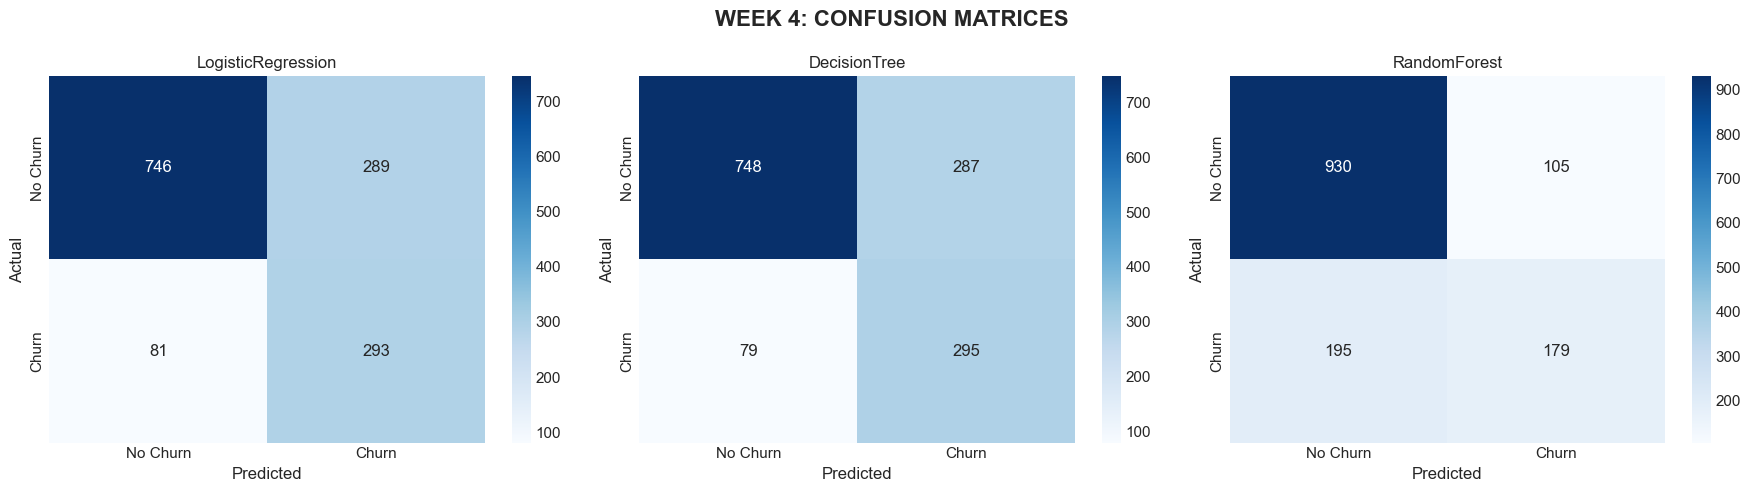


--- 4.4 ROC CURVES ---


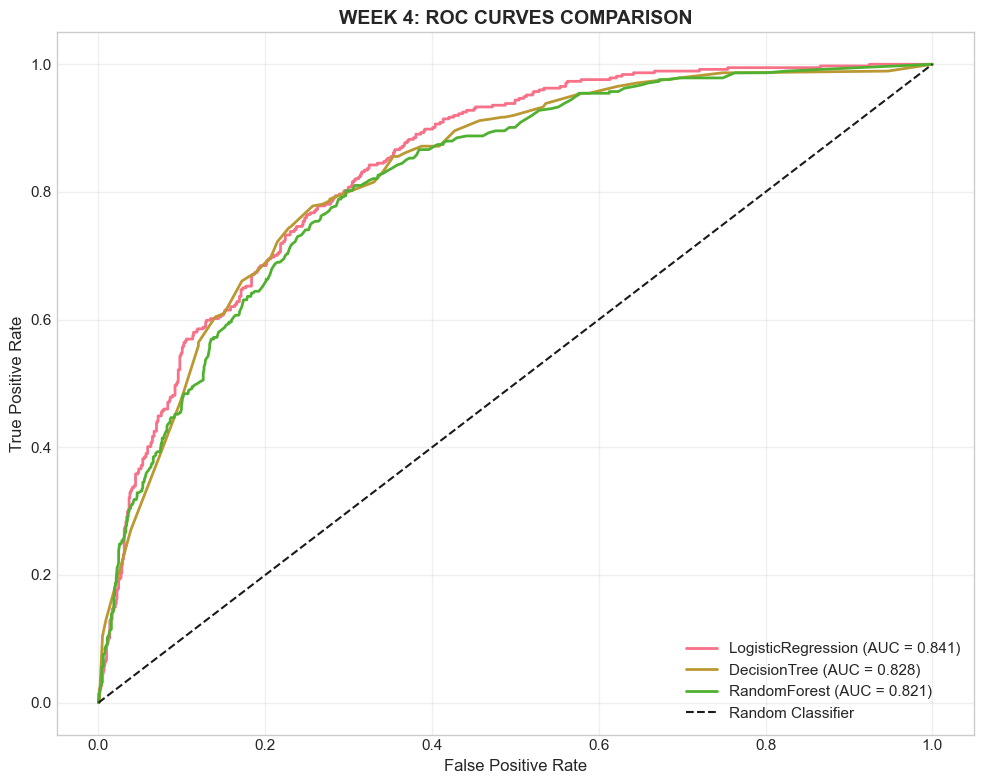


--- 4.5 FEATURE IMPORTANCE (RANDOM FOREST) ---


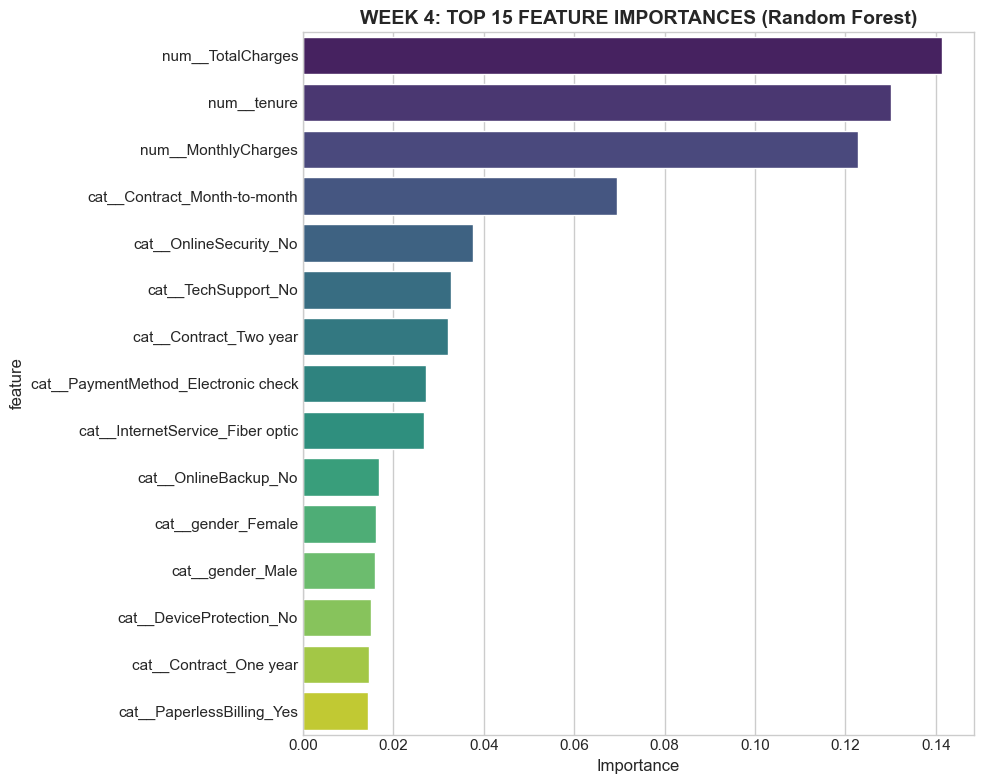

                                feature  importance
2                     num__TotalCharges    0.141372
0                           num__tenure    0.130156
1                   num__MonthlyCharges    0.122676
37         cat__Contract_Month-to-month    0.069360
19               cat__OnlineSecurity_No    0.037704
28                  cat__TechSupport_No    0.032697
39               cat__Contract_Two year    0.032176
44  cat__PaymentMethod_Electronic check    0.027302
17     cat__InternetService_Fiber optic    0.026703
22                 cat__OnlineBackup_No    0.016880

>>> BEST MODEL: Decision Tree (highest F1-Score)


In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

print("\n" + "=" * 80)
print("WEEK 4: MODEL EVALUATION")
print("=" * 80)

# --- 4.0 Generate predictions from Week 3's trained pipelines ---
predictions = {
    name: {
        'y_pred': pipe.predict(X_test),
        'y_proba': pipe.predict_proba(X_test)[:, 1],
    }
    for name, pipe in trained_pipelines.items()
}

# --- 4.1 Evaluation Function ---
def evaluate_model(name, y_true, y_pred, y_proba):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n{'='*50}\nMODEL: {name}\n{'='*50}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-Score:   {f1:.4f}")
    print(f"ROC-AUC:    {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))
    return {'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc}

eval_results = {}
eval_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test,
                    predictions['LogisticRegression']['y_pred'], predictions['LogisticRegression']['y_proba'])
eval_results['Decision Tree'] = evaluate_model('Decision Tree', y_test,
                    predictions['DecisionTree']['y_pred'], predictions['DecisionTree']['y_proba'])
eval_results['Random Forest'] = evaluate_model('Random Forest', y_test,
                    predictions['RandomForest']['y_pred'], predictions['RandomForest']['y_proba'])

# --- 4.2 Model Comparison ---
print("\n--- 4.2 MODEL COMPARISON SUMMARY ---")
comparison_df = pd.DataFrame(eval_results).T
print(comparison_df.round(4))

# --- 4.3 Confusion Matrices ---
print("\n--- 4.3 CONFUSION MATRICES ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WEEK 4: CONFUSION MATRICES', fontsize=16, fontweight='bold')
for idx, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4.4 ROC Curves ---
print("\n--- 4.4 ROC CURVES ---")
plt.figure(figsize=(10, 8))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc = roc_auc_score(y_test, preds['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('WEEK 4: ROC CURVES COMPARISON', fontsize=14, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4.5 Feature Importance (Random Forest) ---
print("\n--- 4.5 FEATURE IMPORTANCE (RANDOM FOREST) ---")
rf_pipe = trained_pipelines['RandomForest']
rf_model = rf_pipe.named_steps['model']
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()

feature_importance = (pd.DataFrame({'feature': feature_names,
                                    'importance': rf_model.feature_importances_})
                      .sort_values('importance', ascending=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), y='feature', x='importance', palette='viridis')
plt.title('WEEK 4: TOP 15 FEATURE IMPORTANCES (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feature_importance.head(10))

best_model_name = comparison_df['f1'].idxmax()
print(f"\n>>> BEST MODEL: {best_model_name} (highest F1-Score)")